# Hands-On Session 1: The Art of Prompting LLMs

## Overview

Welcome to Part 1(a) of our AI workshop series. In this session, you'll dive into the world of prompting large language models (LLMs), gaining some initial familiarity with effectively communicating with LLMs.

## Learning Objectives
By the end of this lab, you will:
1. Craft effective prompts for diverse AI applications
2. Understand and apply various prompting techniques
3. Gain insights into AI safety through hands-on experience

## 0. Using the tech stack

* **Google Colab**: We'll use this free, cloud-based platform for easy setup and access to computational resources. While we're focusing on Colab, you can easily replicate this project in your local computing environment. (You're here!)
* To run "cells" in Colab, either press the "Play" button in the upper left of the cell, or type Shift+Enter (hold down the keys together briefly).

* **LiteLLM**: This library helps streamline interactions with a wide range of pre-trained LLMs. We'll use it to load and run our LLMs, and interact with the LLM.

* **LLM**: We'll start with a handful of OpenAI and Gemini models.

____
## LAB 1-A: Prompting Fundamentals

For this hands-on session, we will explore:

- **Prompt Anatomy**: Explore system instructions, user inputs, and AI responses.
- **Token Mechanics**: Understand what tokens are, how they are used in LLMs, and how to estimate both input and output costs of token use.
- **Conversation Dynamics**: Compare single-turn queries and multi-turn dialogues.

To begin, we need to install litellm in order to have a simple, unified interface to communicate with an LLM

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
#@title Installing Necessary Packages and Imports
%%capture
%pip install litellm==1.102.0 "openai>=2.20.0,<3.0.0" ipydatagrid==1.4.0

import os
import litellm
litellm.drop_params = True

from litellm import completion
from litellm import model_cost
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
from collections import defaultdict
from ipydatagrid import DataGrid

# Workshop API key. Paste the key handed out in the room; do not commit it.
# One key covers every model in this lab, because every call goes through OpenRouter.
# Phase 8 replaces this cell with a call to the hub's /api/env endpoint.
os.environ["OPENROUTER_API_KEY"] = ""

# Fail here, clearly, rather than 20 cells later. With an empty key, llama-index falls
# back to its OpenAI client and reports "Missing credentials ... set OPENAI_API_KEY",
# which sends you looking for the wrong key entirely.
assert os.environ.get("OPENROUTER_API_KEY"), (
    "Paste the workshop key into the line above before running the rest of the notebook.")



In [ ]:
#@title Extract relevant available models given a few constraints

def filter_models_by_cost_and_provider(acceptable_providers: list, mode: str, max_input_cost_per_token_million: float, max_output_cost_per_token_million: float, structured_responses: bool) -> dict:
    """
    Filters models from the global model_cost dictionary based on acceptable providers and max token costs.

    Args:
        acceptable_providers: model families to keep, as they appear in an OpenRouter id
            (the 'openai' in 'openrouter/openai/gpt-4.1-nano').
        mode: The mode of the model. (chat, embedding, etc. Based on LiteLLM)
        max_input_cost_per_token_million: The maximum acceptable input cost per token (in dollars per million tokens).
        max_output_cost_per_token_million: The maximum acceptable output cost per token (in dollars per million tokens).
        structured_responses: A boolean indicating whether we want the model to support structured responses

    Returns:
        A dictionary where keys are provider names and values are lists of model information
        dictionaries that meet the specified criteria, including their blended token cost.
    """
    filtered_models = defaultdict(list)
    for model_name, model_info in model_cost.items():
        # Every call in this lab goes through OpenRouter, so the ids we care about all
        # look like openrouter/<family>/<model>. litellm reports them under one provider,
        # so the family has to come out of the id itself.
        if model_info.get('litellm_provider') != 'openrouter':
            continue
        parts = model_name.split('/')
        if len(parts) < 3:
            continue
        provider = parts[1]

        input_cost_per_token = model_info.get('input_cost_per_token') or 0
        output_cost_per_token = model_info.get('output_cost_per_token') or 0
        model_mode = model_info.get('mode')
        supports_response_schema = model_info.get('supports_response_schema', False)

        if structured_responses and not supports_response_schema:
            continue

        # Convert cost per token to cost per million tokens for comparison
        input_cost_per_token_million = round(input_cost_per_token * 1_000_000, 4)
        output_cost_per_token_million = round(output_cost_per_token * 1_000_000, 4)

        # Calculate blended cost (simple average for now)
        blended_cost_per_token_million = round((input_cost_per_token_million + output_cost_per_token_million) / 2, 4)
        if blended_cost_per_token_million == 0 or model_mode != mode:
            continue
        if provider in acceptable_providers and \
            input_cost_per_token_million <= max_input_cost_per_token_million and \
            output_cost_per_token_million <= max_output_cost_per_token_million:

            # Drop variants that are not a plain chat model: batch endpoints, image and
            # audio output, search-wired models, and the older families.
            short_name = parts[-1]
            if ':' in short_name:
                continue
            if any(tag in short_name for tag in
                   ('image', 'audio', 'tts', 'realtime', 'search', 'preview', 'instruct')):
                continue

            model_info_with_cost = model_info.copy()
            model_info_with_cost['blended_cost_per_token_million'] = blended_cost_per_token_million
            filtered_models[provider].append({model_name: model_info_with_cost})

    return filtered_models

available_models = filter_models_by_cost_and_provider(acceptable_providers=['openai', 'google'],
                                                      mode='chat',
                                                      max_input_cost_per_token_million=3,
                                                      max_output_cost_per_token_million=3,
                                                      structured_responses=True)

# The table above is the survey: everything OpenRouter will serve us under the cost cap.
# The dropdown below uses a shorter list, every entry of which was called successfully
# on 2026-09-20. A model appearing in a catalogue is not the same as a model answering.
VERIFIED_MODELS = [
    'openrouter/openai/gpt-4.1-nano',
    'openrouter/openai/gpt-4.1-mini',
    'openrouter/openai/gpt-5-nano',
    'openrouter/openai/gpt-5-mini',
    'openrouter/google/gemini-2.5-flash',
    'openrouter/google/gemini-2.5-flash-lite',
]


### Create a simple LLM

---
Now let's try making a very simple LLM, technically a text-completion model.

In [ ]:
# Options come from the verified list, not from the filtered catalogue. Every one of
# these was called successfully; offering an option that errors teaches nothing.
all_models_list = VERIFIED_MODELS


# Create the dropdown widget
model_dropdown = widgets.Dropdown(
    options=['Select a model'] + all_models_list,
    value='Select a model',
    description='Model:',
    disabled=False,
)

# Create a text input widget for the prompt
input_text = widgets.Textarea(
    value='What is the elevation of Mount Kilimanjaro?',
    placeholder='Enter your prompt here',
    description='Prompt:',
    layout=widgets.Layout(width='50%', height='100px') ,
    disabled=False
)

# Create a button
submit_button = widgets.Button(description="Submit")


# Output widget to display the table and responses
output_area = widgets.Output()

# Display the output area for the table and responses
display(output_area)

# Function to display model comparison table
def display_model_comparison_table(models_dict):
    data = []
    # Collect data and sort it
    for provider, models_info in models_dict.items():
        for model_data in models_info:
            for model_name, info in model_data.items():
                data.append({
                    'Provider': provider,
                    'Model Name': model_name,
                    'Input Cost (per million tokens)': round(info.get('input_cost_per_token', 0) * 1_000_000, 4),
                    'Output Cost (per million tokens)': round(info.get('output_cost_per_token', 0) * 1_000_000, 4),
                    'Blended Cost (per million tokens)': info.get('blended_cost_per_token_million', 0),
                    'Supports Response Schema': info.get('supports_response_schema', False),
                    'Supports Vision': info.get('supports_vision', False),
                    'Supports Function Calling': info.get('supports_function_calling', False),
                    'RPM (Requests Per Minute)': info.get('rpm', 'N/A'),  # Add RPM
                    'TPM (Tokens Per Minute)': info.get('tpm', 'N/A')    # Add TPM
                })

    if data:
        df = pd.DataFrame(data)
        df_sorted = df.sort_values(by=['Provider', 'Model Name']).reset_index(drop=True)
        with output_area:
            clear_output(wait=True)
            grid = DataGrid(df_sorted)
            grid.auto_fit_columns=True
            display(grid)
        return df_sorted
    else:
        with output_area:
            clear_output(wait=True)
            print("No models available based on the current filter.")
        return None


# Display the initial table
available_models_df = display_model_comparison_table(available_models)

# Arrange dropdown, input text and button vertically below the table
input_widgets = widgets.VBox([model_dropdown, input_text, submit_button])
display(input_widgets)


# Function to handle button click
def on_submit_button_clicked(b):
    selected_model = model_dropdown.value
    user_prompt = input_text.value

    if selected_model == "Select a model":
        with output_area:
            print("Please select a model.")
        return
    if not user_prompt:
        with output_area:
            print("Please enter a prompt.")
        return

    messages = [{"content": user_prompt, "role": "user"}]

    with output_area:
        clear_output(wait=True)
        print(f"Selected model: {selected_model}")
        print("Sending API call...")
        try:
            response = completion(model=selected_model, messages=messages)
            display(Markdown(response.choices[0].message.content))
        except Exception as e:
            print(f"An error occurred: {e}")


# Register the callback function
submit_button.on_click(on_submit_button_clicked)

For those who want to peer a little bit deeper into the response object, take a look at the output from the below cell. Notice a few things:
1. The `model` field comes back as `openai/gpt-5-nano`, the OpenRouter id we asked for, and a `provider` field says which upstream company actually served the call. Calling OpenAI directly would instead return a dated snapshot like `gpt-5-nano-2025-08-07`. Routing is happening one layer away from us now, and the response tells us where it landed.
2. Gpt-5-nano also used a few hundred `reasoning_tokens` for internal "thinking" before producing the final answer. This shows the model's chain-of-thought reasoning process that happens behind the scenes. This is a controlled parameter, but not available for older models. You pay for those tokens.
3. If you had any tools used, like a web search, or a document lookup, it would appear here under your `tool_calls` field.


```python
user_prompt = "What is the elevation of Mount Kilimanjaro?"

messages = [{"content": user_prompt, "role": "user"}]

response = completion(model='openrouter/openai/gpt-5-nano', messages=messages)

print(response.model_dump_json(indent=2))
```
```json
{
  "id": "gen-1789949198-W97aXDBb6ZkkbfYdwn4a",
  "created": 1789949198,
  "model": "openai/gpt-5-nano",
  "object": "chat.completion",
  "system_fingerprint": null,
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "Mount Kilimanjaro\u2019s elevation is 5,895 meters (19,341 feet) above sea level. The summit is Uhuru Peak on the Kibo cone. ...",
        "role": "assistant",
        "tool_calls": null,
        "function_call": null,
        "reasoning_content": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
        "provider_specific_fields": {
          "reasoning": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
          "reasoning_details": [
            {
              "type": "reasoning.summary",
              "summary": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
              "format": "openai-responses-v1",
              "index": 0
            },
            {
              "type": "reasoning.encrypted",
              "data": "gAAAAABqsHUUTI0XUhuWKs19RzyADsemp2cG9vVnydMCPLnwY08h4jQCbf9OC6K0b9WXbnzBmw6608EyUZ9ZQbomqfYOgNUDJnhMS3MdbAfYLzCrPGPS-F1FolAn2RQ3q5c-Sw3wM0ASYKrVozYILLeNexb2auIkK1cnpNH1Fra4VR37GMpGNgUbf8RKMiVqqkNrwo8d3G5iS2OF_NR5MHcLC01NBYbw-ce9__3dUchiXNUD25j2WKpeIBmV2Y2ZwothWXfqLypmkoTuqtvFnQjMWle4bcE4FxBMJsKCUIfL2KjbSUQvge5JznD4JSt_NH1EOlIPwVs-CBIna0j5QHrcXWZcEAXjgjslWfsa0PKZgTLMbVOWUwhyS4MyRQUn4C9HxNE4Dq8oiNZq-mHY8Y1XvpaS3NEo5IGmTFev5PdsG-WCbFyY1_bfEhfz_D45s4DJqHtQttj0GVzikFrczBR8MVBPf1zcMkwESnZsmpfzSc5TJ4vVoNimiOC7DM8k3RDTSg31hARpXEYn1PTSbxu3UCvBxjzBceAuBP1SGkFDfwU0cLDzcdhvfe2M6glHaopvnXyWlzqpMk_6o8S3V3mB1ZxbpJHNLnIILw2QsjeXL1haaZMo8nW989wZ2lT63HBBH_A3onDbGxp0c077ZFIWwRtF_u0ff4efHiuOvnCEPN5q5Ulz-6QLd4gMKgnn8rdbkCjOUtSaOU4RDsCd1OI7BAyjefhWN-6rIb4VSe28wCKlzg0l6av12yzKjWHjDyl5qXqebT6j3QUvzAKnbcmJ6hNfJT7HLAk98oLPS8sg3Extn89bvyVNygsJmGC9O1pnWYY3QmZMyl1QrPDnvYW4kQNSCIb9qqiOVgMFls-1p8z9u176IVaXhh7f6Mv90VNEGsgGWyW7MXp7L18L7Mbun5r3HUYwnCzopZLYmjFdRS1LubkpdoUAg8ZDwFlcL4EXKdOB63ibDjJEbQTwoxwI8PbUBVztDHz9Dd0wRug1yLm0Gp6q7cpY7xDbP_PBUcbR-9knaYIdZ3nMUWw3PwlMLoyB3qeGPB9PzF0EFSUmz3nGgE6Lg9IYZ5nn7YLIQlbaSfxyX2MZBUifMJYbab5Pr5Ebmeg4NKHzTUtQOnFads2m5ikgV8SPwLgi2I65z4HjnmJOI50RDlQmL3TZfMD9mNGhcZyuckhPT4BbeI36uPOSc71lslXZWrLEzKKShSHzCeFw4MwEJmJKS10lwTvreWObgcSjprcBicBW4VbsItIhuVT8xDO2PULIepzjPVklwEC8dal9poCBEPZZBUmDAinFhc2W89h5KDDqqIv9AVJ_oWZlgAVgZqDp-Dah-IIcXvCXAh3nNsBZDoF92kW-76oJZKh_tvvooGAWPorV8Q25ITLX5HuXVCQHnC3IDNZ1FDu3GgKsi6bCDL0CxeZmtWp8T-JOLz1ZoDg8Ej5mQ8UPZ1igbHoU2NhuRkTg-G_pOMWyT1ZGRXJe1W-yg82H07Vk7HN3H_nwjzjcNHEwuwaKgB1e5Q-aNSqKDscwELyu3xOWkxW7Vc0TkwYksN0-5ZKgJS2LrgoX_gHGiVMtNzrssgaLS3Q76dtu9Aw5P_pEl-ikGhsjkPzLZqPoYUZ-kBW8Rk6TsHHtObdWqpPAyG68RiNDtIymrFq6VecuEM3ubmrIBSmjNb6GWHnji6Nn1mCtNEvnN-HISNpnjI-QFrEUrCrR7jlmYkt72NcjmPvFt8Ksg1jDp_vyGO7Xf0VaW9rsBAWpWMJm7HQVbRgf9vDCTphzltsyH91H5vFN_PdxhJXtCoW-RTFjVaEHRg4olADq0jUy5LWulkHMehbGK5IwvpQyk4k4kbovQpca2ouf0VOmsFeysaxcFBwljH_xl8quIUtYmSpVLnpRHKBmWXH12_rHlmXBSTly3M5OXMacp1_zeckHadxyWvYZrKB1jrFG3oRF7K-UJVkFG8s3Bfu9Wan5BZWIkIHgMXOxjAkeUSzmuawRHgHasIeHhPpwAVBXhiMK6FXWkgDJcAYTh6tEkd3YpGzbK7GCjsdMlQHEwObczSS7u8zpbAGAL7E6Hs1Avmcsz3qulyhqqLatEqCWzUEsS038yvu0U5UHtc-ZOzCojGv4bkjoG0VBamzeaTX5FPb90PYEgoHOoJrwXmtjFZQEGzTeGeXXawnJ6XuqaHjfvggk8EmP9xfHjvpqYSNHFegEWhqAIBT8jGVAJ3AUy7PTku_6ihPEU-Hg8qdyZFQ68zK7im5uX7uQPUrqurL7iykVQY9Y83Vry0UfpQC0-kw181ca5HKljfGNMXZhWBRieBvsTMIi0d9_3PpzwibTApjDURk8NTkAzI_bMtPD-GuLDy9DhFzXpxOaqEnS3I-_E5PnSLRAeMjsIeXZYLoGTEZVQak1m4WgAMkzZQ5s-eERHWVTMhgXejr_CPdDzMlXCee1fWOmiPFRPlexUfdtveBItTDP0ONM4lvEcjzm1NRT0ji-M5R6e44So1wrvqaVAclXZ649E2rPr-m_77dMPzhwtqk8aMlo3Bct6hyA1kyEXBBfMFL1e180N-nJp7DdTXYK91W82cu0oz2oh-YqzFhH9iJ2W8G109cwwUBChjJgX9pcTi1HTqFVVzr0SF_caLJ8LZyJdPtJ_AqYTqejJfmPY46pN6gHFxRwgKUgrVGyLp37sKQq6cW1D3Uc4TJHwgceUmMpfQg4TOAF5Qx0v4ky6tHDSXccPNG4V_-URG-0Ltd_V3dQucITFLn8AeCpsf0mY3hVQ4FjzVLvLJfWBCp6Ls9_JIoFaT2ga-YLCxRxam2iA3x2B7E_umZQES71sL4MgoQybRs1KtnoONjbR9JMcsDiavqe56Veffx0TaQ7kOjI_qrYtLxTaUVCjZiy2vW091uHeCjosUchXf4f8yiFPqnH4A-gz_2pfG5kDLJFq8DVvB-nRYOWcy5VjBGnY10J1RGvRK0FKI5AAt2J-jp0QcSvAK1aA4fjhjxukPgr5mMpKn4nHOv4gFcmUv7QvhnhzxSqwd9075DW3u8hzoB8YVc_i27V2N0vKlrnno7Mxdw3odrhmTzwDuEVGdcCGvxxEsIRe8UR_DdcFWrGgmMzjGAQvVSKcjO2ck1Pda9HzQ0_yHoNt_eFLhsmdAcBpK3M74IvYPnNjSmYuPYLd8YnYj8I_n_Z3272FJl8-qIeGfEU-bNtio2yyVhMSlDUlzRT60AhGjIJowjAqY7EGTYR-GJetJpdhbt_1-ncDEamiJYUAGKVM_rxreIexzLPRdWNIQsbXCxMaw3M0025KfQnMNhdopMxGyvKWild6jQIQY2tIgjQut1VZzuzwfH8U9Zyh3bVrqqIyMZsjzxkSlWCx8Q_o8-Kmml-PoQiT-3JEU9OzrH_A_yzcqsrddKnTFnAPjiEXOMgxre3oPJm-OkwoHvc8lgILTm0zkNiNNn55_zgVOacM0TXqZSY7_01INH6vGfRm8VaJZUXhIhZQN5_gpYJW5kt5vNIVjSx8GYmwXKN6bSK9UQ6kRu_pzHMTB1lZ8M4yg51cXqjNb0Nrhj8pZOMR3goGLIno5B2b3lzMl1VfhFvCc1NIWXSnul2rRwlyg2XXf_8JHIsobrlf1z4gRNelNgsleFCVJzGBE6ZKyScSXg85pUa30F-Y3ldzJk4PC8qOkcdhiRYic7UzTPDFLm3PNIB2kmyRMWN7Y24oW2ocsNFGn4aN0eJC8R5APq3qa7xgfvp27WdhnZHLPwPEyeQKetq8n6Sy93t9sQ-l7Z5SAoFTIjPUz4exW2AS_y30hmqcE1rW5I7fWpzy5YoxLjpDNEdgzbucYHPYPkQjT3aeToKaepD7bNgShMvEYbN-FmxaDpQz9Jmn1wfvebRwJtT7inI26V6KDoLSVq4da1kOtw2bY7lAfolDzklUBW-ATqTSoD1vasHGVGxgB2LBQpSLVVATTOIPpPcIBpiH74=.eyJlbmRwb2ludF9zbHVnIjoib3BlbmFpL2dwdC01LW5hbm8tMjAyNS0wOC0wN3xvcGVuYWkifQ",
              "format": "openai-responses-v1",
              "id": "rs_0a61b4ab2eacd8c8016ab0750e69ac87d1b0d31d548c0283ff",
              "index": 1
            }
          ],
          "refusal": null
        }
      },
      "provider_specific_fields": {
        "native_finish_reason": "completed"
      }
    }
  ],
  "usage": {
    "completion_tokens": 547,
    "prompt_tokens": 17,
    "total_tokens": 564,
    "completion_tokens_details": {
      "accepted_prediction_tokens": null,
      "audio_tokens": 0,
      "reasoning_tokens": 448,
      "rejected_prediction_tokens": null,
      "text_tokens": null,
      "image_tokens": 0,
      "video_tokens": null
    },
    "prompt_tokens_details": {
      "audio_tokens": 0,
      "cache_write_tokens": 0,
      "cached_tokens": 0,
      "text_tokens": null,
      "image_tokens": null,
      "video_tokens": 0,
      "cache_creation_tokens": 0
    },
    "cost": 0.00021965,
    "is_byok": false,
    "cost_details": {
      "upstream_inference_cost": 0.00021965,
      "upstream_inference_prompt_cost": 8.5e-07,
      "upstream_inference_completions_cost": 0.0002188
    }
  },
  "provider": "OpenAI",
  "service_tier": "default"
}
```


Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

**Congratulations**, you just created & programmatically interacted with your first LLM. 🎉



### Task 1

Enter a new "prompt_factoid" below to test the LLM's responses.

Try:

*   Changing the question to a different 'factoid';
*   Asking a more open-ended question;
*   Asking a more business-specific question.


*You can also go back to the previous code above and change the LLM model! Notice how the same prompt can have significantly different responses.*


In [ ]:
llm_model = "openrouter/google/gemini-2.5-flash" #@param ['openrouter/openai/gpt-4.1-nano', 'openrouter/openai/gpt-4.1-mini', 'openrouter/openai/gpt-5-nano', 'openrouter/openai/gpt-5-mini', 'openrouter/google/gemini-2.5-flash']

user_prompt = "Tell me something interesting" # @param {"type":"string","placeholder":"Tell me a joke"}

messages = [{"content": user_prompt, "role": "user"}]

print("Sending API call...")
response = completion(model=llm_model,
                      messages=messages,
                      temperature=0.3)
display(Markdown(response.choices[0].message.content))


Sending API call...


Did you know there's an animal that is considered **biologically immortal**?

It's called the **Turritopsis dohrnii**, or more commonly, the **immortal jellyfish**.

Here's why it's so fascinating: When this tiny jellyfish faces stress (like injury, starvation, or even just old age), instead of dying, it can revert itself back to an earlier stage of its life cycle – essentially transforming back into a polyp. It's like a butterfly turning back into a caterpillar, then into an egg, and starting its life all over again.

While it can still be eaten by predators or die from disease, its unique ability to reset its biological clock means it doesn't die of "old age" in the traditional sense. Scientists are studying it to understand the secrets of aging and regeneration!

**PAUSE** here. Did you do the task above? What did you learn?

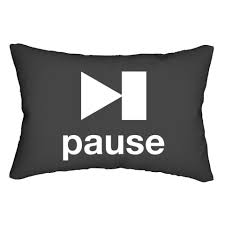

## Create a Chat LLM
---
Now let's try creating a slightly-more sophisticated model, a Chat LLM.

What makes a chat model different from another LLM? A Chat LLM can engage in dialogue, going back & forth with the user, unlike a text-completion LLM which responds (once) to a (single) prompt. Therefore, we'll have to create a slightly more complex set of prompts to interact with the model, including System Messages and User (or Human) Messages.

### Prompt Anatomy

We usually think of a "prompt" as a simple piece of text that we send to a model, as we have been doing thus far. But prompts can include more than that. For example, they might include **system instructions** (like, "Act as an expert in Python programming") or different **parameters** like temperature to control randomness.

There are three types of messages with an LLM:

* **system messages** describe the behavior of the AI assistant. A useful system message for data science use cases is "You are a helpful assistant who understands data science."
* **user messages** describe what you want the AI assistant to say. We'll cover examples of user messages throughout this tutorial
* **assistant messages** describe previous responses in the conversation. We'll cover how to have an interactive conversation later in this lab.

The first message should be a system message. Additional messages should alternate between the user and the assistant.

Let's create a chat LLM, then be a little more specific about our prompts to it.

In [ ]:
# Feel free to select a new LLM from our list.
llm_model = "openrouter/openai/gpt-4.1-nano" #@param ['openrouter/openai/gpt-4.1-nano', 'openrouter/openai/gpt-4.1-mini', 'openrouter/openai/gpt-5-nano', 'openrouter/openai/gpt-5-mini', 'openrouter/google/gemini-2.5-flash']

# Define the system message
SYSTEM_MESSAGE = 'You are a helpful assistant who understands the business of interior decorating.'

# Define the user message
USER_MESSAGE = 'What color paint should I use for a living room in a house in the mountains near Denver?'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": USER_MESSAGE, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1, stream=True)
res_so_far = ""
for part in response:
  if part.choices[0].delta.content:
    res_so_far += part.choices[0].delta.content
  print(res_so_far)
  clear_output(wait=True)

Okay, let's brainstorm some paint color ideas for your mountain living room near Denver! To give you the best recommendations, I need a little more information, but I can definitely get us started with some great options.

**First, let's consider the style and feel you're aiming for:**

*   **Rustic & Cozy:** Think warm, inviting, and connected to nature.
*   **Modern Mountain:** Clean lines, natural materials, and a more contemporary feel.
*   **Traditional:** Classic and comfortable, with a touch of elegance.
*   **Eclectic:** A mix of styles, colors, and textures.

**Here are some general color palettes that work beautifully in mountain settings:**

*   **Earthy Neutrals:**
    *   **Warm Grays/Greiges:** These are incredibly versatile. Look for shades like Benjamin Moore's "Revere Pewter" (a classic) or Sherwin-Williams' "Agreeable Gray." They provide a neutral backdrop that complements wood tones and natural textures.
    *   **Creamy Whites:** Think of the snow-capped peaks! Whit

In [ ]:
display(Markdown(res_so_far))

For a living room in a mountain home near Denver, consider colors that complement the natural surroundings and create a cozy, inviting atmosphere. Here are some paint color suggestions:

1. Earthy Neutrals: Warm taupes, soft beiges, or creamy off-whites echo the natural landscape and give a warm, welcoming feel.
2. Forest Greens: Deep greens inspired by pine trees can bring the outdoors in and add richness to the space.
3. Slate Grays: A medium to dark gray with blue undertones reflects the mountain skies and stone, offering a modern yet snug vibe.
4. Warm Terracotta or Rust: These shades add warmth and a southwestern touch that fits well with Colorado’s rustic charm.
5. Soft Blues: Light blues reminiscent of the clear mountain sky can create a calming, airy environment.

Also, consider the amount of natural light your living room receives and choose a finish that suits your lifestyle, such as matte for a cozy look or eggshell for easier cleaning. Accenting with natural wood tones and stone elements will further enhance the mountain feel. Would you like suggestions for coordinating accent colors or decor styles?

### Task 2

Try setting a different `SYSTEM_MESSAGE` variable in the below cell and see how it impacts the response.

Try:

*   Changing the role of the system;
*   Setting a "stylized" response for the system (e.g.: 'in the style of Gandalf from The Hobbit');
*   Etc.


In [ ]:
# Define the system message
SYSTEM_MESSAGE = "You are a paint expert" #@param {"type": "string"}

# Define the user message
USER_MESSAGE = 'What color paint should I use for a living room in a house in the mountains near Denver?'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": USER_MESSAGE, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1)
display(Markdown(response.choices[0].message.content))

For a living room in a mountain home near Denver, you'll want to choose colors that complement the natural surroundings and create a cozy, inviting atmosphere. Here are some suggestions:

1. **Earthy Neutrals:** Warm beiges, taupes, or soft greys can mimic the rocky landscapes and provide a calm backdrop.
2. **Forest Greens:** Deep greens inspired by pine trees add a touch of nature and work well with wooden furniture or accents.
3. **Warm Terracotta or Rust:** These colors echo the mountain earth tones and add warmth and depth.
4. **Soft Blues:** Light blue or slate tones can reflect the sky and distant mountains, offering a serene vibe.
5. **Creamy Whites:** For a bright, airy feeling that keeps the room fresh while allowing other natural materials to stand out.

Consider also the amount of natural light your living room receives. In spaces with ample sunlight, deeper, richer colors work beautifully, while lighter hues can brighten darker rooms.

If you want a more rustic, cozy feel, pair these colors with textured materials like wood beams, stone accents, and cozy textiles. Would you like recommendations on specific paint brands or color codes?

**PAUSE** here. Did you do the task above? What did you learn?

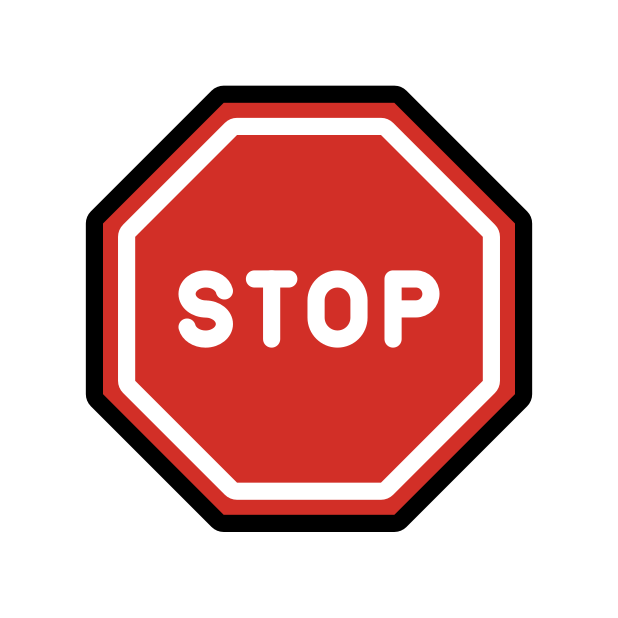

**STOP** here - end of Lab 1-A.

## LAB 1-B Complex Prompting

### Prompt Templates

Our prompts are starting to get a little complicated, with different types of messages and enforced order.

Let's explore the use of a "**prompt template**" to help with all of this, giving us a structured starting point for our prompts to pass to the chat *LLM*.

In [18]:
from typing import List, Dict
import pydantic

class SimplePromptTemplate(pydantic.BaseModel):
    city: str

    def format_string(self) -> str:
        return f"What color paint should I use for a house in {self.city}?"


In [19]:
# Provide the value for the placeholder to create the prompt
City = "La Crosse" #@param {"type": "string"}
filled_prompt = SimplePromptTemplate(city=City.strip()).format_string()
print(filled_prompt)

What color paint should I use for a house in La Crosse?


In [20]:
# Define the system message
SYSTEM_MESSAGE = 'You are a helpful assistant who understands the business of interior decorating specifically in Wisconsin.'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": filled_prompt, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1)
display(Markdown(response.choices[0].message.content))

Okay, choosing a paint color for your house in La Crosse, Wisconsin is exciting! Here's a breakdown to help you decide, considering La Crosse's environment, architectural styles, and some popular trends:

**1. Consider the Architectural Style of Your House:**

*   **Victorian:** La Crosse has a beautiful stock of Victorian homes. For these, consider rich, historic palettes. Think:
    *   **Body:** Sage greens, deep blues (like navy or indigo), muted golds, or creamy off-whites.
    *   **Trim:** Contrasting colors like burgundy, deep reds, or a lighter shade of the body color for accents.
    *   **Accent:** A pop of color on the door – think vibrant reds, deep greens, or even a bright yellow.
*   **Craftsman/Bungalow:** These homes often benefit from earth tones.
    *   **Body:** Warm grays, browns, olive greens, or muted yellows.
    *   **Trim:** Creamy whites, contrasting browns, or darker shades of the body color.
    *   **Accent:** A natural wood stain door or a pop of color like a deep teal or burnt orange.
*   **Mid-Century Modern:** Lean into the retro vibes.
    *   **Body:** Light grays, beiges, off-whites, or even a muted pastel.
    *   **Trim:** Crisp white or a contrasting color like charcoal gray or black.
    *   **Accent:** A bright door in a color like orange, turquoise, or yellow.
*   **Modern/Contemporary:** Clean lines call for a simpler palette.
    *   **Body:** Grays (light to dark), whites, or even a bold color like navy or charcoal.
    *   **Trim:** White or a contrasting color.
    *   **Accent:** A bold door or interesting architectural details highlighted in a contrasting color.
*   **Ranch:** Consider a welcoming and comfortable palette
    *   **Body:** soft beige, light gray, or a muted sage green
    *   **Trim:** Classic white or a warm cream
    *   **Accent:** A front door in a cheerful color like coral, sky blue, or a natural wood stain.

**2. Think About the Environment and Landscape:**

*   **Mississippi River Influence:** La Crosse is a river town. Colors that complement the natural surroundings often work well. Think about the tones of the water, the bluffs, and the trees.
*   **Four Distinct Seasons:** Wisconsin experiences all four seasons. Colors that look good year-round are ideal.
*   **Sunlight:** Consider how much direct sunlight your house gets. Darker colors can fade faster in strong sunlight. Lighter colors can reflect sunlight and make a house feel cooler in the summer.

**3. Neighborhood Context:**

*   **Don't clash:** While you want your house to stand out in a good way, avoid choosing colors that are completely out of sync with the rest of the neighborhood.
*   **Consider HOA rules:** If you live in a neighborhood with a Homeowners Association (HOA), be sure to check their guidelines regarding exterior paint colors.

**4. Current Trends (with a La Crosse Twist):**

*   **Nature-Inspired Neutrals:** Warm grays, greiges (gray-beige), and off-whites are still popular choices. These work well with La Crosse's natural surroundings.
*   **Earthy Greens:** Sage greens, olive greens, and forest greens are trending, bringing a sense of calm and connection to nature.
*   **Blues:** Navy blue, deep teal, and even lighter, more muted blues are popular choices for siding or accents.
*   **Black Accents:** Black trim and doors are a modern and sophisticated way to add contrast.
*   **Warm Accents:** Copper and brass fixtures are very popular and can add a nice touch to a door or porch.

**5. Important Considerations:**

*   **Undertones:** Pay attention to undertones! Grays can have blue, green, or beige undertones. Whites can be cool or warm. Test paint samples in different lighting conditions to see how the undertones appear.
*   **Paint Quality:** Invest in high-quality exterior paint that is designed to withstand Wisconsin's weather.
*   **Professional Consultation:** Consider hiring a local interior designer or paint consultant for personalized advice. They can help you choose colors that will complement your home's style, surroundings, and personal preferences. I suggest you contact a Sherwin Williams or a competitor that has local representation in La Crosse.

**Recommendations:**

*   **For a classic, timeless look:** A warm gray with white trim and a navy blue door.
*   **For a more modern look:** A light gray with black trim and a bright yellow door.
*   **For a historic look:** A sage green with burgundy trim and a deep red door.

To help me narrow down the best choices for *your* house, tell me a little more:

*   **What is the architectural style of your house?**
*   **What colors do you like?**
*   **What colors are the neighboring houses?**
*   **Is there any existing stonework or brick that needs to be considered?**

I can give you more specific recommendations once I have a better understanding of your situation!


### Token Mechanics

Our goals in this section are to understand what tokens are, how they are used in LLMs, and how to estimate both input and output costs of token use. Tokens can be thought of as pieces of words. Before the LLM API processes a request, the input is broken down into *tokens*. These tokens are not necessarily defined by exactly where the words start or end - tokens can include trailing spaces and even sub-words.

* For hands-on exploration of tokenization, you can use OpenAI's [interactive Tokenizer tool](https://platform.openai.com/tokenizer), which allows you to calculate the number of tokens and see how text is broken into tokens.

* You can find details on OpenAI's token pricing [here](https://openai.com/pricing).

Let's first look at an extremely simple example of tracking token usage for a single LLM call.

In [26]:
USER_INPUT = 'Can you tell me the name of the best movie of all time?'
response = completion(model=llm_model,temperature=0.8,
                      messages=[{'role': 'user', 'content': USER_INPUT}])

display(Markdown(response.choices[0].message.content))

print(f"Usage Information:\n{response.json()['usage']}")

Ah, the million-dollar question! There's no single "best movie of all time" because it's completely subjective. What one person finds a masterpiece, another might find boring or overrated.

However, I can tell you about some films that consistently appear on "best of" lists and are widely considered classics:

*   **Citizen Kane (1941):** Often cited for its innovative storytelling and technical achievements.
*   **The Godfather (1972):** A crime epic with unforgettable characters and a powerful narrative.
*   **Casablanca (1942):** A romantic drama with iconic lines and a timeless story.
*   **2001: A Space Odyssey (1968):** A visually stunning and thought-provoking science fiction film.
*   **Pulp Fiction (1994):** A groundbreaking and influential crime film with a unique style.
*   **Schindler's List (1993):** A moving and important historical drama.
*   **Lawrence of Arabia (1962):** An epic adventure film with stunning cinematography.
*   **Seven Samurai (1954):** A classic samurai film that has influenced countless others.
*   **Vertigo (1958):** A suspenseful and atmospheric thriller.
*   **The Dark Knight (2008):** Considered a landmark in the superhero genre.

These movies are often praised for their:

*   **Storytelling:** Compelling narratives, well-developed characters, and meaningful themes.
*   **Directing:** Visionary direction that brings the story to life.
*   **Acting:** Memorable performances that resonate with audiences.
*   **Technical achievements:** Innovative cinematography, editing, and sound design.
*   **Cultural impact:** Films that have influenced other movies and popular culture.

Ultimately, the "best movie of all time" is the one that resonates most with *you*. I recommend exploring different genres, directors, and eras to discover your own personal favorites!

To help you find your own best movie, consider:

*   **What genres do you enjoy?**
*   **What kind of stories do you find compelling?**
*   **What directors or actors do you admire?**

Happy watching!


Usage Information:
{'completion_tokens': 487, 'prompt_tokens': 14, 'total_tokens': 501, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': None, 'text_tokens': 14, 'image_tokens': None}}


### Task 3

Notice that if you rerun the above cell multiple times, you will get different prompt outputs and costs (total tokens) associated with it!

Try running that code a few more times.
* Does the output change?
* Does the output change if you change the prompt?
* Does the output change if you make the prompt more complex?

In [28]:
### For this example, we will set the llm_model to gemini-2.5-flash
llm_model = "openrouter/google/gemini-2.5-flash"
USER_INPUT = 'Can you tell me the name of the best movie of all time?'

response = completion(model=llm_model,temperature=0.3,
                      messages=[{'role': 'user', 'content': USER_INPUT}])

display(Markdown(response.choices[0].message.content))

print(f"Usage Information:\n{response.json()['usage']}")

That's a fantastic question, but also one of the most debated and subjective! There isn't a single, universally agreed-upon "best movie of all time" because what makes a film "best" depends entirely on individual taste, cultural background, critical criteria, and even what you're looking for in a movie.

However, I can tell you some of the films that are most frequently cited by critics, filmmakers, and audiences as contenders for that title:

**Often Topping Critic Polls & Historically Significant:**

*   **Citizen Kane (1941):** Frequently cited for its revolutionary cinematography, narrative structure, and deep character study. It topped the British Film Institute's Sight & Sound poll (a major critics' poll) for 50 years.
*   **Vertigo (1958):** Alfred Hitchcock's psychological thriller, which dethroned Citizen Kane in the 2012 Sight & Sound poll and again in 2022.
*   **2001: A Space Odyssey (1968):** Stanley Kubrick's groundbreaking science fiction epic, praised for its visual effects, philosophical themes, and ambiguity.

**Popular & Critically Acclaimed Masterpieces:**

*   **The Godfather (1972):** Often considered a masterpiece of storytelling, acting, and filmmaking. It consistently ranks at the top of many audience and critic polls (like IMDb's top 250).
*   **The Shawshank Redemption (1994):** While not always topping critic polls, it consistently holds the #1 spot on IMDb's user-rated list, beloved for its inspiring story and powerful performances.
*   **Casablanca (1942):** A timeless classic known for its iconic dialogue, memorable characters, and enduring romance.

**Other Highly Influential & Acclaimed Films:**

*   **Seven Samurai (1954):** Akira Kurosawa's epic, influential, and often imitated masterpiece.
*   **Pulp Fiction (1994):** Quentin Tarantino's genre-bending, non-linear crime film that redefined independent cinema.
*   **Parasite (2019):** A modern masterpiece that won the Academy Award for Best Picture and Best International Feature, praised for its sharp social commentary and thrilling plot.

So, while I can't give you *the* definitive name, these are some of the strongest contenders that many people would argue for! What do *you* consider the best?

Usage Information:
{'completion_tokens': 1317, 'prompt_tokens': 15, 'total_tokens': 1332, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 786, 'rejected_prediction_tokens': None, 'text_tokens': 531}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': None, 'text_tokens': 15, 'image_tokens': None}}


**PAUSE** here. Did you do the task above? What did you learn?

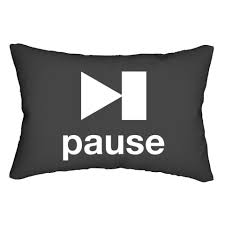

### Model Experimentation

For the second part of our lab, we will perform:

- **Model Comparison**: Evaluate different LLMs
- **Parameter Experimentation**: Experiment with temperature, top_p and other parameter settings
- **Advanced Techniques**: Practice zero-shot, few-shot, and Chain-of-Thought prompting

**Model Comparison**

Let's start by comparing OpenAI's `gpt-4.1-nano` with Gemini's `gemini-2.5-flash`.

Check to see if the responses differ at all from the previous responses you received.

In [ ]:
available_models_df['Model Name'].values

In [34]:
prompt_to_test = "how to test the effectiveness of an llm?"



gpt_4_1_nano_response = completion(model='openrouter/openai/gpt-4.1-nano',temperature=0.8,
                      messages=[{'role': 'user', 'content': prompt_to_test}])

gemini_2_5_flash_response = completion(model='openrouter/google/gemini-2.5-flash',temperature=0.8,
                      messages=[{'role': 'user', 'content': prompt_to_test}])

print("gpt-4.1-nano response:")
display(Markdown(gpt_4_1_nano_response.choices[0].message.content))
print("Gemini-2.5-flash response:")
display(Markdown(gemini_2_5_flash_response.choices[0].message.content))


Gemini-2.0-flash response:


Testing the effectiveness of an LLM is a multifaceted process that depends heavily on the specific task and desired outcomes. Here's a breakdown of different approaches and considerations:

**1. Define the Task and Objectives:**

*   **What is the LLM supposed to do?** Be specific. Examples:
    *   Summarize news articles.
    *   Answer questions about a knowledge base.
    *   Generate creative content (stories, poems, code).
    *   Translate text between languages.
    *   Classify customer reviews (positive, negative, neutral).
    *   Perform sentiment analysis.
    *   Generate SQL queries from natural language.
*   **What are the key performance indicators (KPIs)?** How will you measure success?  Examples:
    *   **Accuracy:** How often does it give the correct answer?
    *   **Completeness:** Does it cover all relevant information?
    *   **Fluency:** Is the output grammatically correct and natural-sounding?
    *   **Coherence:** Does the output make sense and follow a logical flow?
    *   **Relevance:** Is the output pertinent to the input query?
    *   **Speed:** How quickly does it generate the output?
    *   **Cost:** How much does it cost to generate the output (e.g., API usage)?
    *   **Bias:** Does the output exhibit undesirable biases?
    *   **Safety:** Does the output avoid generating harmful or offensive content?
    *   **Hallucination:** Does the output invent facts or information?

**2. Data Preparation:**

*   **Gather a Dataset:**  You need a dataset relevant to the task.
    *   **Size:** The size of the dataset is crucial.  Larger datasets generally lead to more reliable evaluations.
    *   **Diversity:** Ensure the dataset covers a wide range of inputs and scenarios.
    *   **Ground Truth:**  You need a "ground truth" or "gold standard" against which to compare the LLM's output.  This is often manually created and verified.
    *   **Split the Dataset:** Divide the dataset into training, validation, and testing sets (if you are fine-tuning the model).  If you are just evaluating a pre-trained model, you mainly need a validation and testing set.
*   **Data Cleaning and Preprocessing:** Clean the data to remove noise, inconsistencies, and irrelevant information.  This can involve:
    *   Removing duplicates
    *   Correcting errors
    *   Standardizing formatting
    *   Tokenization

**3. Evaluation Metrics and Methods:**

This is where the specific methods depend on the task.  Here's a breakdown by common task types:

*   **Question Answering:**
    *   **Exact Match (EM):**  Does the LLM's answer exactly match the ground truth? (Strict)
    *   **F1 Score:**  Harmonic mean of precision and recall between the LLM's answer and the ground truth.  (More forgiving than EM)
    *   **ROUGE (Recall-Oriented Understudy for Gisting Evaluation):**  Measures the overlap of n-grams (sequences of words) between the LLM's answer and the ground truth.  Commonly used for summarization and QA.  Variants include ROUGE-N (N-gram overlap), ROUGE-L (longest common subsequence), and ROUGE-S (skip-bigram overlap).
    *   **BLEU (Bilingual Evaluation Understudy):**  Originally designed for machine translation, measures the similarity between the LLM's answer and one or more reference answers.  Penalizes brevity.
    *   **BERTScore:**  Uses contextual embeddings from BERT to measure semantic similarity between the LLM's answer and the ground truth.  Captures meaning beyond simple word overlap.
    *   **Human Evaluation:**  Have humans rate the quality, relevance, and accuracy of the answers.  This is often the most reliable but also the most expensive.

*   **Text Summarization:**
    *   **ROUGE (Recall-Oriented Understudy for Gisting Evaluation):** (See description above)
    *   **BLEU (Bilingual Evaluation Understudy):** (See description above)
    *   **Human Evaluation:** (See description above)
    *   **Compression Ratio:**  The ratio of the length of the summary to the length of the original text.  (Important for extractive summarization)
    *   **Coherence and Fluency Metrics:**  Assess the readability and logical flow of the summary.

*   **Text Generation (Creative Writing, Code Generation):**
    *   **Perplexity:**  Measures how well the LLM predicts the next word in a sequence. Lower perplexity generally indicates a better model.  (Useful for training but less so for direct evaluation of output quality)
    *   **BLEU (Bilingual Evaluation Understudy):** (See description above, can be used if reference outputs exist)
    *   **Human Evaluation:**  Essential for assessing the creativity, originality, and overall quality of the generated text.  Consider aspects like:
        *   **Relevance to the Prompt:** Does the output fulfill the prompt's requirements?
        *   **Coherence and Fluency:** Is the output well-written and easy to understand?
        *   **Creativity and Originality:** Does the output demonstrate imagination and novel ideas?
        *   **Engagement:** Is the output interesting and captivating?
    *   **For Code Generation:**
        *   **Execution Success Rate:**  How often does the generated code execute successfully?
        *   **Code Correctness:**  Does the code produce the desired output?
        *   **Code Efficiency:**  How efficient is the generated code in terms of runtime and resource usage?
        *   **Code Style:**  Does the code adhere to coding best practices and style guidelines?

*   **Machine Translation:**
    *   **BLEU (Bilingual Evaluation Understudy):** (See description above)
    *   **METEOR (Metric for Evaluation of Translation with Explicit Ordering):**  Another metric that considers synonyms and stemming, addressing some limitations of BLEU.
    *   **TER (Translation Edit Rate):**  Measures the number of edits (insertions, deletions, substitutions) needed to transform the LLM's translation into a reference translation.
    *   **Human Evaluation:** (See description above)

*   **Text Classification (Sentiment Analysis, Topic Classification):**
    *   **Accuracy:**  The percentage of correctly classified instances.
    *   **Precision:**  The proportion of correctly predicted positive instances out of all instances predicted as positive.
    *   **Recall:**  The proportion of correctly predicted positive instances out of all actual positive instances.
    *   **F1 Score:**  Harmonic mean of precision and recall.
    *   **AUC (Area Under the ROC Curve):**  Measures the ability of the model to distinguish between different classes.
    *   **Confusion Matrix:**  A table that summarizes the classification results, showing the number of true positives, true negatives, false positives, and false negatives.

*   **Bias and Safety Testing:**
    *   **Bias Detection Datasets:** Use datasets specifically designed to identify biases in language models (e.g., datasets with demographic attributes).
    *   **Adversarial Attacks:**  Craft inputs designed to trigger biased or harmful outputs.
    *   **Human Evaluation:**  Have humans review the output for signs of bias or harmful content.
    *   **Safety Benchmarks:** Use established safety benchmarks to assess the model's ability to avoid generating harmful or offensive content.

**4. Implementation:**

*   **Automated Evaluation:**  Whenever possible, automate the evaluation process using scripts and libraries. This allows for faster and more reproducible results.
*   **Statistical Significance:**  Consider the statistical significance of your results.  Small differences in metrics may not be meaningful.
*   **Error Analysis:**  Analyze the cases where the LLM performs poorly.  This can provide valuable insights into the model's weaknesses and areas for improvement.

**5. Tools and Libraries:**

*   **Hugging Face Transformers:**  A popular library for working with pre-trained language models. Includes tools for evaluation.
*   **NLTK (Natural Language Toolkit):**  A Python library for natural language processing.  Provides functions for tokenization, stemming, and other tasks.
*   **Scikit-learn:**  A Python library for machine learning.  Provides metrics for classification and regression.
*   **SacreBLEU:**  A standardized implementation of BLEU.
*   **Rouge:** A Python implementation of ROUGE.
*   **GPT-3/GPT-4 Evaluation APIs:** OpenAI and other providers offer APIs for evaluating their models on specific tasks.  This can be convenient but also expensive.
*   **Prompt Engineering Tools:** Tools that help you design and test prompts to elicit the desired behavior from the LLM.
*   **Bias Detection Libraries:** Libraries such as Fairlearn or Aequitas can help you detect and mitigate bias in your models.

**6. Considerations for Different Model Types:**

*   **Closed-Source Models (e.g., GPT-4, Bard):**  You primarily interact with these models through APIs.  Evaluation is often limited to prompt engineering and analyzing the API's outputs.  You may not have access to the model's internals for fine-grained analysis.
*   **Open-Source Models (e.g., Llama 2, Falcon):**  You have more control over these models. You can fine-tune them on your own data and perform more in-depth analysis of their behavior.

**7. Iterative Improvement:**

Evaluation is not a one-time process.  Use the evaluation results to:

*   **Refine Prompts:**  Experiment with different prompts to see how they affect the LLM's performance.
*   **Fine-Tune the Model:**  If you have access to the model's weights, fine-tune it on your own data to improve its performance on specific tasks.
*   **Choose a Different Model:**  If the current model is not performing well, consider using a different model that may be better suited for the task.
*   **Adapt Evaluation Methods:** Based on the insights from previous evaluations, adjust the metrics and methods used to better capture the desired outcomes.

**In Summary:**

Testing the effectiveness of an LLM is a complex and iterative process.  It requires careful planning, data preparation, selection of appropriate metrics, and thorough analysis.  The specific methods used will depend on the task, the desired outcomes, and the available resources. Don't rely on a single metric; use a combination of automated metrics and human evaluation to get a comprehensive understanding of the LLM's performance.


Gemini-2.5-flash response:


Testing the effectiveness of an LLM is a multifaceted process that requires a combination of automated metrics, human evaluation, and real-world user testing. There's no single "magic bullet" test; the best approach depends heavily on the specific application and goals of your LLM.

Here's a comprehensive guide:

---

## 1. Define "Effectiveness" for Your LLM

Before you test, you *must* clearly define what "effective" means in your specific context. Ask:

*   **What is the LLM's primary purpose?** (e.g., chatbot, summarizer, code generator, creative writer, Q&A system, data extractor)
*   **Who are the target users?**
*   **What are the key performance indicators (KPIs)?**
    *   **Accuracy/Factuality:** Is the information correct?
    *   **Relevance:** Does the output directly address the prompt?
    *   **Coherence/Fluency:** Is the language natural, grammatically correct, and easy to understand?
    *   **Helpfulness/Utility:** Does it solve the user's problem or achieve their goal?
    *   **Safety/Harmlessness:** Does it avoid generating toxic, biased, illegal, or unethical content?
    *   **Conciseness:** Is it to the point without unnecessary verbosity?
    *   **Creativity/Originality:** (for creative tasks)
    *   **Consistency:** Does it perform similarly across similar prompts?
    *   **Speed/Latency:** How quickly does it respond?
    *   **Cost-effectiveness:** (Less about effectiveness, more about deployment, but relevant for practical use).

---

## 2. Evaluation Methods

### A. Human Evaluation (The Gold Standard)

Human judgment is invaluable for assessing nuanced qualities that automated metrics often miss.

**How to do it:**

1.  **Develop Clear Rubrics:** Create detailed guidelines for human evaluators, defining what constitutes a "good" or "bad" response for each KPI (e.g., a 1-5 scale for accuracy, relevance, helpfulness, safety).
2.  **Curate Diverse Prompts:**
    *   **Representative Prompts:** A wide range of typical user queries.
    *   **Edge Cases:** Ambiguous, complex, domain-specific, or challenging prompts.
    *   **Adversarial Prompts (Red Teaming):** Intentionally designed to elicit harmful, biased, or incorrect responses (see section D).
3.  **Use Multiple Raters:** Have at least 2-3 independent human evaluators rate each response to ensure reliability and identify areas of disagreement (Inter-Rater Reliability - IRR).
4.  **Blind Evaluation:** If comparing multiple LLMs (or different versions of your own), evaluators should not know which model generated which response.
5.  **Tools:** Use internal dashboards, crowdsourcing platforms (e.g., Scale AI, Appen, Amazon Mechanical Turk), or specialized LLM evaluation platforms.

**Pros:** Captures nuance, common sense, creativity, safety, and subjective quality that automated metrics cannot.
**Cons:** Expensive, time-consuming, subjective (requires careful rubric design and rater training), limited scalability.

### B. Automated Evaluation (Scalable but Limited)

Automated metrics are great for quick, scalable assessments and tracking progress, but they often don't fully correlate with human judgment.

**How to do it:**

1.  **Standard Benchmarks:**
    *   **General Language Understanding:** MMLU (Massive Multitask Language Understanding), HELM (Holistic Evaluation of Language Models), BIG-bench, GLUE, SuperGLUE.
    *   **Reasoning:** GSM8K (math), ARC (science QA).
    *   **Code Generation:** HumanEval, MBPP.
    *   **Factuality:** TruthfulQA.
    *   **Safety/Bias:** BBQ (Bias Benchmark for QA), RealToxicityPrompts.
    *   **Specialized Benchmarks:** Look for benchmarks relevant to your specific domain (e.g., medical, legal, financial).
2.  **Task-Specific Metrics (Requires Ground Truth):**
    *   **Text Generation (Summarization, Translation, Paraphrasing):**
        *   **BLEU (Bilingual Evaluation Understudy):** Measures n-gram overlap with reference translations.
        *   **ROUGE (Recall-Oriented Understudy for Gisting Evaluation):** Measures overlap of n-grams, word sequences, and word pairs (common for summarization).
        *   **METEOR:** Combines precision and recall, considers synonyms.
        *   **BERTScore:** Uses BERT embeddings to calculate semantic similarity, often correlates better with human judgment than n-gram based metrics.
        *   **ChrF:** Character n-gram F-score, good for morphology-rich languages.
    *   **Classification:** Precision, Recall, F1-score, Accuracy.
    *   **Question Answering:** Exact Match (EM), F1-score (for span-based QA).
    *   **Perplexity (Intrinsic Metric):** Measures how well the LLM predicts a sample of text (lower is generally better, but doesn't always reflect usefulness).
3.  **LLM-as-a-Judge:** Use a stronger, larger LLM to evaluate the output of a smaller LLM. This is an emerging technique, but it has its own biases and limitations.

**Pros:** Fast, scalable, objective (for what it measures), useful for tracking progress and hyperparameter tuning.
**Cons:** Can be "gamed," often don't fully capture semantic meaning, common sense, or user satisfaction; require ground truth data.

### C. User Testing & A/B Testing (Real-World Utility)

This is crucial for understanding how your LLM performs in the hands of actual users.

**How to do it:**

1.  **Qualitative User Testing:**
    *   **Usability Studies:** Observe users interacting with the LLM.
    *   **Think-Aloud Protocols:** Ask users to verbalize their thoughts and expectations.
    *   **User Interviews:** Gather feedback on satisfaction, pain points, and suggestions.
2.  **Quantitative User Testing / A/B Testing:**
    *   **A/B Test:** Deploy two versions of the LLM (or a new version vs. a baseline) to different user groups and compare performance.
    *   **Collect User Feedback:** Implement "thumbs up/down," "was this helpful?" buttons, or feedback forms directly in the UI.
    *   **Monitor User Behavior:**
        *   **Task Success Rate:** Percentage of users who successfully complete their goal.
        *   **Time to Completion:** How long it takes users to achieve their goal.
        *   **Engagement Metrics:** Number of turns per conversation, session duration, return rate.
        *   **User Satisfaction Scores:** Net Promoter Score (NPS), System Usability Scale (SUS).
        *   **Error Rates:** How often the LLM provides incorrect or unhelpful responses.
        *   **Escalation Rate:** How often users escalate to a human agent (for chatbots).

**Pros:** Measures real-world utility, user satisfaction, and identifies actual pain points.
**Cons:** Requires live users, can be slow to gather data, ethical considerations (user privacy, potential for negative experiences).

### D. Adversarial Testing / Red Teaming (Robustness and Safety)

Actively try to break the LLM and uncover its vulnerabilities.

**How to do it:**

1.  **Safety & Ethics Probing:**
    *   Attempt to elicit toxic, hateful, biased, or sexually explicit content.
    *   Probe for misinformation or conspiracy theories.
    *   Try to get the LLM to endorse illegal activities or give harmful advice.
2.  **Bias Detection:**
    *   Test with prompts that expose gender, racial, religious, or other demographic biases.
    *   Use datasets designed for bias evaluation (e.g., StereoSet, CrowS-Pairs).
3.  **Factual Error / Hallucination Detection:**
    *   Ask questions about obscure facts.
    *   Request summaries of non-existent articles or books.
    *   Ask for details about current events that are not yet widely known.
4.  **Robustness Testing:**
    *   **Prompt Injection:** Try to manipulate the LLM's instructions.
    *   **Out-of-Distribution Inputs:** Feed it unusual or nonsensical prompts.
    *   **Ambiguity:** Test its ability to handle vague or ambiguous queries.
    *   **Context Window Limits:** Test how it performs with very long or very short contexts.

**Pros:** Crucial for identifying critical safety and ethical issues, improves robustness and trustworthiness.
**Cons:** Can be resource-intensive, requires creative "attackers," the space of possible attacks is infinite.

---

## 3. Key Considerations & Best Practices

*   **Iterative Process:** LLM effectiveness testing is not a one-time event. It should be an ongoing, iterative process throughout development and deployment.
*   **Establish Baselines:** Always compare your LLM's performance against previous versions, other models, or even human performance.
*   **Diverse Data:** Use a diverse and representative dataset of prompts and desired outputs for both training and evaluation. Avoid overfitting to your test set.
*   **Combine Methods:** The most effective testing strategy combines automated metrics (for scale), human evaluation (for nuance), and user testing (for real-world impact).
*   **Observability & Monitoring:** Once deployed, continuously monitor your LLM's performance, user feedback, error logs, and key metrics. Set up alerts for unexpected behavior.
*   **Ethical Review:** Integrate ethical considerations into every stage of testing, especially regarding bias, fairness, and safety.
*   **Cost vs. Benefit:** Balance the rigor of your testing with the resources available and the criticality of the application.

By employing a thoughtful combination of these methods, you can gain a comprehensive understanding of your LLM's effectiveness and continuously improve its performance.

**PAUSE**, and consider the above. Play with it! Try other questions!

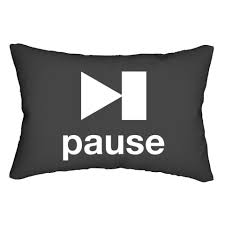

### Parameter Experimentation

Try simple things like changing the temperature of the model.

In [35]:
# gpt-4.1-nano on purpose. The gpt-5 models ignore `temperature` entirely, and
# litellm.drop_params = True hides that by silently dropping the argument.
for temperature in [0, 0.5, 1]:
  print(f"Temperature = {temperature}:")
  response = completion(model='openrouter/openai/gpt-4.1-nano',temperature=temperature,
                      messages=[{'role': 'user', 'content': "Why is the sky blue? Answer in 30 words or less"}])
  display(Markdown(response.choices[0].message.content))

Temperature = 0:


The sky is blue because of Rayleigh scattering. Air molecules scatter blue light from the sun more than other colors, making the sky appear blue in our eyes.


Temperature = 0.5:


The sky appears blue because of Rayleigh scattering. Air molecules scatter blue light from the sun more than other colors, making it visible in all directions.


Temperature = 1:


The sky is blue because of a phenomenon called Rayleigh scattering. Blue light from the sun is scattered more than other colors by the tiny air molecules in Earth's atmosphere.


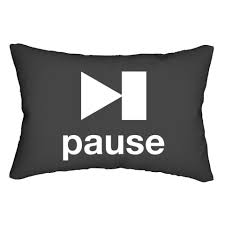

**PAUSE** here. What did you notice about the different temperature settings?

### Advanced Techniques

Practice zero-shot, few-shot, and Chain-of-Thought prompting.

**Zero-Shot Prompting**

Zero-shot prompting occurs when a model is asked to perform a task without any prior examples or context about how to perform that specific task. The prompt must be self-contained, as the model relies solely on its pre-trained knowledge to generate a response.

Example Prompt:
* Summarize the key impacts of the 2020 global pandemic on remote work trends.

In this case, the model is expected to understand what is being asked and use its internal knowledge to provide a summary without any additional examples or guidance.


In [36]:
# try zero-shot
prompt = "Summarize the top 3 key impacts of the 2020 global pandemic on remote work trends."
res_zero = completion(model='openrouter/google/gemini-2.5-flash',temperature=1,
                      messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_zero.choices[0].message.content))

The 2020 global pandemic had three key impacts on remote work trends:

1.  **Rapid, Widespread Adoption and Normalization:** It forced an unprecedented, immediate shift to remote work for millions globally, transforming it from a niche benefit or occasional practice into a mainstream, often mandatory, mode of operation. This proved its viability at scale for many industries.
2.  **Accelerated Investment in Remote Work Technology and Infrastructure:** Companies rapidly adopted and invested heavily in collaboration tools (video conferencing, project management, cloud services) and cybersecurity to support their distributed workforces. This significantly matured the technology ecosystem for remote work.
3.  **Permanent Redefinition of Workplace Expectations and Models:** The experience fundamentally altered employee expectations regarding flexibility, autonomy, and work-life integration. This led to the widespread embrace of hybrid work models, a greater focus on outcomes over presence, and a broader talent pool, as geographic limitations became less significant for many roles.


**Few-Shot Prompting**

Few-shot prompting involves providing a few examples to the model before presenting the actual task. This approach helps the model understand the desired format or the specific type of response needed.

Example Prompt:

```
Example 1: Translate the English phrase "Hello, how are you?" to Spanish.
Answer: Hola, como estás?

Example 2: Translate the English phrase "What time is it?" to Spanish.
Answer: Qué hora es?

Prompt: Translate the English phrase "Where is the nearest restaurant?" to Spanish.
```

Here, the model is shown two examples of translation tasks, which sets the expectation that it should translate the third phrase from English to Spanish in a similar format.

In [37]:
# try few-shot prompting
prompt = """
  Below are a few examples, followed by the prompt for you to follow.

  Example 1: Translate the English phrase "Hello, how are you?" to Spanish.
  Answer: Hola, como estás?

  Example 2: Translate the English phrase "What time is it?" to Spanish.
  Answer: Qué hora es?

  Prompt: Translate the English phrase "Where is the nearest restaurant?" to Spanish."""

res_few = completion(model='openrouter/google/gemini-2.5-flash',temperature=1,
                    messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_few.choices[0].message.content))

Answer: Dónde está el restaurante más cercano?

**Chain-of-Thought Prompting**

Chain-of-Thought prompting guides the model through a logical sequence of steps or thoughts to reach a conclusion, particularly useful for complex reasoning tasks. This method helps models handle problems that require multiple inferential steps.

Example Prompt:

```
Question: A farmer has 17 sheep, and all but 9 die. How many are left alive?
Chain of Thought: The phrase "all but 9 die" means that 9 sheep remain alive.
Answer: 9
```

In this example, the prompt explicitly outlines the reasoning process needed to answer the question, leading the model to the correct interpretation and response.

In [ ]:
# try chain-of-thought prompting
prompt = """
  I will pose a question, and you will provide your chain-of-thought reasoning to reach the answer.

  Question: A farmer has 17 sheep, and all but 9 die. How many are left alive?"""

res_cot = completion(model='openrouter/openai/gpt-4.1-nano',temperature=1,
                    messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_cot.choices[0].message.content))


Here's my chain of thought:

1. **Understand the problem:** The question describes a scenario where sheep die.
2. **Identify the key information:** The farmer starts with 17 sheep, and "all but 9" die.
3. **Interpret "all but 9":**  This means that 9 sheep *survive* and the rest die.
4. **Determine the answer:** The question asks how many are *left alive*.

Answer: 9


**Usage Tips:**

* **Zero-Shot**: Useful when querying general knowledge or opinions, or when the task is straightforward.
* **Few-Shot**: Effective for tasks that require specific formats or where a model needs examples to "learn" the task quickly.
* **Chain-of-Thought**: Best for complex reasoning, mathematics, or multi-step logical problems.

## 3. AI Safety Challenge

For the third and final part of this lab, we will do a:

- **Prompt Hacking Exercise**: Test the limits of AI safety with the Gandalf challenge*
  - URL: https://gandalf.lakera.ai/baseline
  - Objective: Attempt to "hack" the AI chatbot using creative prompting techniques
  - Time: Utilize any remaining lab time to see if you can get through all of the levels!

*Note: For further exploration, look into safety tools like Meta's Prompt Guard and LLaMA Guard.
